# Análise de Stemming — CETENFolha

Experimento de stemming aplicado ao corpus CETENFolha-1.0, comparando os algoritmos
PorterStemmer, SnowballStemmer (português) e RSLPStemmer sobre os 100 primeiros artigos.

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd                    # Manipulação de DataFrames
import matplotlib.pyplot as plt        # Geração de gráficos
from nltk.stem import *                # Importa todos os stemmers do NLTK (Porter, RSLP, etc.)
from nltk.stem import SnowballStemmer  # Import explícito do Snowball (não incluso no wildcard)
from collections import Counter        # Contagem de frequência de elementos

## 1. Teste com PorterStemmer (Inglês)

Validação do ambiente usando o PorterStemmer sobre palavras em inglês.
Este algoritmo não é adequado para português, sendo usado aqui apenas como referência.

In [3]:
testStemmer = PorterStemmer()  # Instancia o stemmer de Porter (projetado para inglês)

In [ ]:
# Lista de palavras em inglês com diferentes sufixos (-es, -ed, -ing, -tion, -er, etc.)
words = ['caresses', 'flies', 'dies', 'mules', 'denied', 'died', 'agreed', 'owned', 'humbled', 'sized', 'meeting', 'stating', 'siezing', 'itemization', 'sensational', 'traditional', 'reference', 'colonizer', 'plotted']

In [ ]:
# Aplica o stemmer a cada palavra da lista, retornando a stem correspondente
singles = [testStemmer.stem(word) for word in words]

In [6]:
# Exibe todas as stems separadas por espaço para comparação visual com as palavras originais
print(' '.join(singles))

caress fli die mule deni die agre own humbl size meet state siez item sensat tradit refer colon plot


### Resultado do PorterStemmer

- Cada palavra foi reduzida à sua raiz pela remoção de sufixos comuns do inglês (`-es`, `-ed`, `-ing`, `-tion`)
- Stems não precisam ser palavras válidas — o objetivo é agrupar variantes morfológicas (ex. `flies → fli`, `itemization → item`)
- Este algoritmo é exclusivo para inglês e **não será usado no restante do experimento**

## 2. SnowballStemmer para Português

Definição do stemmer principal e das funções auxiliares que serão aplicadas ao dataset.
O SnowballStemmer é baseado no algoritmo de Paice/Husk, com suporte nativo ao português.

In [7]:
stemmer = SnowballStemmer('portuguese')  # Instancia o Snowball configurado para português

In [ ]:
def applyStemming(text): # Método para aplicar stemming em uma palavra
    """Aplica stemming a cada palavra de uma string, retornando o texto com as stems."""
    return " ".join(stemmer.stem(word) for word in str(text).split())  # split() tokeniza por espaço, stem() reduz cada token

def applyStemmingToDataset(dataset, inColumn, outColumn="stemmedText"): # Método para aplicar stemming em uma coluna de dados/palavras (melhor visualização)
    """Aplica stemming a uma coluna do DataFrame e salva o resultado em uma nova coluna."""
    dataset[outColumn] = dataset[inColumn].astype(str).apply(applyStemming)  # astype(str) garante que valores NaN não quebrem o split
    return dataset

## 3. Carregamento do Dataset

Leitura do corpus CETENFolha pré-processado (100 artigos, sem tags XML, codificado em UTF-8)
e aplicação do SnowballStemmer sobre cada linha de texto.

In [9]:
# Lê o arquivo do corpus, removendo linhas em branco e espaços extras
with open('dataset/CETENFolha-100artigos.txt', 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]  # strip() remove \n e espaços; filtra linhas vazias

df = pd.DataFrame(lines, columns=['text'])  # Cria DataFrame com uma coluna 'text'
df.head()

,text
0,PT no governo
1,Gilberto Dimenstein
2,BRASÍLIA Pesquisa Datafolha publicada hoje rev...
3,"Tem sentido -- aliás, muitíssimo sentido ."
4,"Muito mais do que nos tempos na ditadura, a so..."


### Estrutura do dataset

- Cada linha corresponde a uma sentença ou parágrafo extraído dos 100 primeiros artigos do CETENFolha
- Texto corrido em português, sem tags XML, codificado em UTF-8
- O DataFrame possui uma única coluna `text`

In [10]:
# Aplica o SnowballStemmer sobre a coluna 'text', criando a coluna 'stemmedText'
df = applyStemmingToDataset(df, 'text')
df.head()

,text,stemmedText
0,PT no governo,pt no govern
1,Gilberto Dimenstein,gilbert dimenstein
2,BRASÍLIA Pesquisa Datafolha publicada hoje rev...,brasíl pesquis datafolh public hoj revel um da...
3,"Tem sentido -- aliás, muitíssimo sentido .","tem sent -- aliás, muitíssim sent ."
4,"Muito mais do que nos tempos na ditadura, a so...","muit mais do que nos temp na ditadura, a solid..."


### Resultado do SnowballStemmer

- A coluna `stemmedText` contém o resultado do stemming aplicado palavra a palavra
- Exemplos de reduções: `governo → govern`, `Pesquisa → pesquis`, `publicada → public`, `muitíssimo → muitíssim`
- Stopwords e pontuação permanecem no texto — não houve pré-processamento de remoção nesta etapa

## 4. Frequência de Stems — SnowballStemmer

Contagem das stems geradas pelo Snowball. As mais frequentes tendem a ser stopwords e
preposições, que não foram removidas do corpus nesta etapa.

In [11]:
# Concatena todas as stems em uma única string e tokeniza por espaço
all_stems = ' '.join(df['stemmedText']).split()
stem_counts = Counter(all_stems)  # Conta a frequência de cada stem

top10 = stem_counts.most_common(10)  # Seleciona as 10 stems mais frequentes

print("=== Top 10 Stems ===")
for stem, count in top10:
    print(f"{stem}: {count}")

=== Top 10 Stems ===
.: 336
de: 305
o: 226
a: 213
que: 137
do: 134
e: 124
da: 102
em: 79
par: 72


### Interpretação das frequências

- As stems mais frequentes são pontuação (`.`) e palavras funcionais (`de`, `o`, `a`, `que`, `do`, `e`, `da`, `em`)
- Comportamento esperado em qualquer corpus sem remoção de stopwords
- A stem `par` (72 ocorrências) é a primeira com conteúdo semântico — agrupa palavras como `para`, `parte`, `parcela`
- Para uma análise mais informativa, seria necessário aplicar uma lista de stopwords antes da contagem

## 5. RSLPStemmer

O RSLP (Removedor de Sufixos da Língua Portuguesa) é um algoritmo desenvolvido
especificamente para o português brasileiro. Aplicado ao mesmo corpus para comparação.

In [12]:
rslp = RSLPStemmer()  # Instancia o RSLP (Removedor de Sufixos da Língua Portuguesa)

# Aplica o RSLP sobre a coluna 'text' e salva em 'stem_rslp'
df['stem_rslp'] = df['text'].astype(str).apply(
    lambda text: ' '.join(rslp.stem(w) for w in text.split())  # Mesma lógica do applyStemming, usando RSLP
)

# Contagem de frequência das stems geradas pelo RSLP
all_stems_rslp = ' '.join(df['stem_rslp']).split()
stem_counts_rslp = Counter(all_stems_rslp)

top10_rslp = stem_counts_rslp.most_common(10)

print("=== Top 10 RSLP Stems ===")
for stem, count in top10_rslp:
    print(f"{stem}: {count}")

=== Top 10 RSLP Stems ===
.: 336
de: 305
o: 226
a: 213
do: 174
que: 137
da: 129
e: 124
em: 79
no: 74


### Comparação com o Snowball

- O ranking do RSLP é semelhante ao do Snowball nas primeiras posições (dominado por stopwords)
- Diferenças sutis: `do` sobe de 134 para 174 ocorrências, `no` aparece no top 10 (74), enquanto `par` sai da lista
- Isso reflete a estratégia mais agressiva do RSLP — palavras que o Snowball reduzia a `par` podem ter sido reduzidas a stems diferentes, redistribuindo as contagens

In [13]:
# Re-instancia ambos os stemmers para a comparação direta
snowball = SnowballStemmer('portuguese')
rslp = RSLPStemmer()

# Extrai o vocabulário único do corpus original (set elimina duplicatas)
unique_words = set(' '.join(df['text']).split())

## 6. Comparação entre Snowball e RSLP

Identificação das divergências entre os dois algoritmos sobre o vocabulário do corpus.
Diferenças evidenciam as estratégias distintas de cada abordagem: o RSLP tende a ser
mais agressivo na remoção de sufixos em português.

In [14]:
# Gera lista de tuplas (palavra, stem_snowball, stem_rslp) apenas onde os resultados divergem
differences = [
    (word, snowball.stem(word), rslp.stem(word))
    for word in unique_words
    if snowball.stem(word) != rslp.stem(word)
]

print(f"Total de palavras únicas: {len(unique_words)}")
print(f"Divergências entre Snowball e RSLP: {len(differences)}")

# Exibe as primeiras 30 divergências em ordem alfabética, formatadas em colunas
print(f"\n{'Palavra':<20} {'Snowball':<20} {'RSLP':<20}")
print("-" * 60)
for word, s, r in sorted(differences)[:30]:
    print(f"{word:<20} {s:<20} {r:<20}")

Total de palavras únicas: 3209
Divergências entre Snowball e RSLP: 660

Palavra              Snowball             RSLP                
------------------------------------------------------------
'técnica             'técnic              'técn               
(Fundação            (fundaçã             (fund               
(Serviço             (servic              (serviç             
(agora               (agor                (ag                 
(editora             (editor              (edi                
(«Nem                («nem                («n                 
AMERICANO            american             americ              
ARTES                artes                art                 
Abreu                abreu                abr                 
Adolescente          adolescent           adolesc             
Airbus               airbus               airbu               
Algo                 algo                 alg                 
Alto                 alto                 alt   

### Análise das divergências

- Das 3.209 palavras únicas, **660 (~20,6%) recebem stems diferentes** entre os dois algoritmos
- O RSLP produz stems mais curtas e agressivas (ex. `Bombeiros → bomb` vs. `bombeir`, `Aprendizagem → aprendiz` vs. `aprendizag`)
- Maior agressividade pode aumentar o recall em recuperação de informação, mas também introduz mais colisões entre palavras semanticamente distintas (ex. `Arizona → ari`)

## 7. Distribuição de Frequência

Visualização da distribuição das stems seguindo a Lei de Zipf: poucas stems concentram
a maior parte das ocorrências, enquanto a grande maioria aparece raramente (hapax legomena).

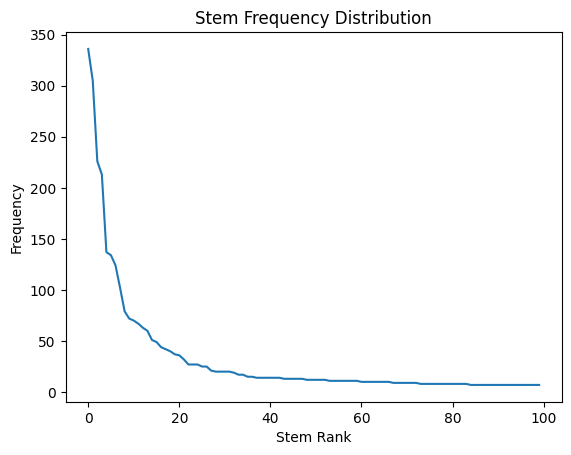

In [15]:
# Ordena as frequências em ordem decrescente para plotar a curva de Zipf
counts = sorted(stem_counts.values(), reverse=True)

# Plota as 100 stems mais frequentes (rank no eixo X, frequência no eixo Y)
plt.plot(counts[:100])
plt.xlabel('Stem Rank')
plt.ylabel('Frequency')
plt.title('Stem Frequency Distribution')
plt.show()

### Interpretação do gráfico

- A curva confirma a **Lei de Zipf** — poucas stems concentram a maioria das ocorrências, enquanto a cauda longa é formada por centenas de stems raras (*hapax legomena*)
- Distribuição característica de qualquer corpus de linguagem natural
- Reforça a importância da remoção de stopwords para análises de frequência voltadas ao conteúdo semântico